# <a id="#">Task 3 – Mean, median, and Gaussian filtering</a>

In [1]:
import numpy
import matplotlib.pyplot as plt

---

## Linear filtering by convolution (mean filter)

**<a id="#">Task 3.1.1.</a>** Load the image `data/astronaut.png` and show it:

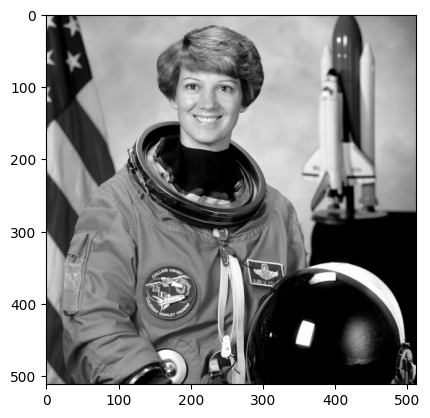

In [22]:

img = plt.imread('data/astronaut.png')
plt.imshow(img, 'gray')

**<a id="#">Task 3.1.2.</a>** Implement a mean filter:

In [55]:
def meanfilter(img_in, size):
    result = numpy.zeros(img_in.shape)
    n = (size - 1) // 2
    for p in numpy.ndindex(img_in.shape):
        neighborhood_sum = 0
        
        for q in numpy.ndindex(size, size):
            neighbor_row = p[0] + q[0] - n
            neighbor_col = p[1] + q[1] - n
            if 0 <= neighbor_row < img_in.shape[0] and 0 <= neighbor_col < img_in.shape[1]:
                neighborhood_sum += img_in[neighbor_row, neighbor_col]
                
        
        result[p] = neighborhood_sum / (size*size)
    return result

In [60]:
def meanfilter(img_in, size):
    result = numpy.zeros(img_in.shape)
    n = (size - 1) // 2
    
    # r = row, c = column
    for r in range(img_in.shape[0]):
        for c in range(img_in.shape[1]):
            # Wir schneiden das Fenster aus: 
            # max/min sorgen dafür, dass wir nicht aus dem Bild fallen
            window = img_in[max(0, r-n) : min(img_in.shape[0], r+n+1), 
                            max(0, c-n) : min(img_in.shape[1], c+n+1)]
            
            # numpy.mean berechnet die Summe und teilt durch die ANZAHL der Pixel im Fenster
            result[r, c] = numpy.mean(window)
            
    return result


In [65]:
def meanfilter(img_in, size):
    # Erstelle ein leeres Bild (Nullen) in der Größe des Originals
    result = numpy.zeros(img_in.shape)
    # Radius berechnen
    n = (size - 1) // 2
    
    # Durch jedes Pixel p des Bildes laufen
    for p in numpy.ndindex(img_in.shape):
        neighborhood_sum = 0
        
        # Durch das Fenster q laufen
        for q in numpy.ndindex(size, size):
            # Position des Nachbarn berechnen
            ni = p[0] + q[0] - n
            nj = p[1] + q[1] - n
            
            # Boundary Check: Nur aufsummieren, wenn wir im Bild sind
            if 0 <= ni < img_in.shape[0] and 0 <= nj < img_in.shape[1]:
                neighborhood_sum += img_in[ni, nj]
        
        # WICHTIG für Convolution: Immer durch die volle Fläche teilen!
        # Das entspricht einem Padding mit Nullen am Rand.
        result[p] = neighborhood_sum / (size * size)
        
    return result


**<a id="#">Task 3.1.3.</a>** Test your implementation from above by using the function `meanfilter` for the previously loaded image and show the result:

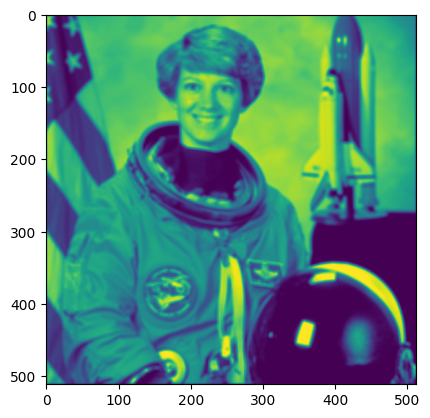

In [66]:
img_in = img.copy()
img_new = meanfilter(img_in, 5)
plt.imshow(img_new)

**<a id="#">Task 3.1.4.</a>** Compare your result for filter size `5` with the correct result image `data/astronaut_meanfilter5.png`:

In [69]:
img_in = img.copy()
img_new = meanfilter(img_in, 5)
img_new = numpy.round(img_new * 255) / 255


img_two = plt.imread('data/astronaut_meanfilter5.png')


assert numpy.allclose(img_new, img_two, atol=1/255)




AssertionError: 

---

## Non-linear filtering

**<a id="#">Task 3.2.1.</a>** Implement a median filter:

In [ ]:
def medianfilter(img_in, size):
    result = numpy.zeros(img_in.shape)
    ...
    return result

**<a id="#">Task 3.2.2.</a>** First, test your implementation from above by using the function `medianfilter` for the previously loaded image and show the result:

Then, compare your result for filter size `5` with the correct result image `data/astronaut_medianfilter5.png`:

---

## Using pre-implemented filters

**<a id="#">Task 3.3.1.</a>** Load the package `scipy.ndimage`:

**<a id="#">Task 3.3.2 (a).</a>** Apply a **mean filter** from `scipy.ndimage` to the loaded image:

**<a id="#">Task 3.3.2 (b).</a>** Apply a **median filter** from `scipy.ndimage` to the loaded image:

**<a id="#">Task 3.3.2 (c).</a>** Apply a **Gaussian filter** from `scipy.ndimage` to the loaded image:

**<a id="#">Task 3.3.3.</a>** Compare the results obtained using the functions from `scipy.ndimage` with those you obtained using your own implementations. What are the main differences? Do you have an explanation?

---

## Slicing and benchmarking

**<a id="#">Task 3.4.2.</a>** Implement either a mean filter or a median filter using only a single `for`-loop:

In [ ]:
def fastfilter(img_in, size):
    ...

**<a id="#">Task 3.4.3.</a>** First, test your implementation from above by using the function `fastfilter` for the previously loaded image and show the result:

Then, compare your result to those obtained using your implementation for either `meanfilter` or `medianfilter`, respectively:

**<a id="#">Task 3.4.4.</a>** Benchmark the code run times:

**<a id="#">Task 3.4.5.</a>** Document your observations regarding the benchmarking results and try to think of an explanation: